In [3]:
# Import the required libraries
import pandas as pd
import numpy as np

In [4]:
# Load the dataset
df = pd.read_csv("dataset/spam.csv", encoding="latin-1")

In [5]:
# Display the first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
# Display information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [7]:
# Display the number of rows and columns
df.shape

(5572, 5)

In [8]:
# Display column names
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [9]:
# Remove unnecessary columns
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

In [10]:
# Rename the columns
df.columns = ['label', 'message']

In [11]:
# Display the first 5 rows after cleaning
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
# Check for missing values
df.isnull().sum()

label      0
message    0
dtype: int64

In [13]:
# Count duplicate rows
df.duplicated().sum()

np.int64(403)

In [14]:
# Remove duplicate rows
df = df.drop_duplicates()

In [15]:
df.shape

(5169, 2)

In [16]:
# Count the number of spam and ham messages
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [17]:
# Display percentage of each class
df['label'].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

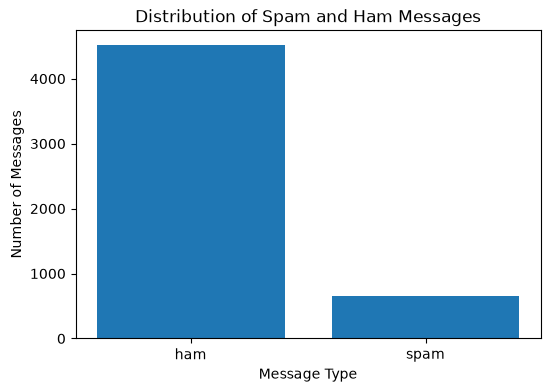

In [18]:
import matplotlib.pyplot as plt

# Count spam and ham messages
counts = df['label'].value_counts()

# Create bar chart
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)

# Add title and labels
plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

# Display the chart
plt.show()

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

In [20]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['message'])

X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 68018 stored elements and shape (5169, 8672)>

In [21]:
vectorizer = CountVectorizer()

In [22]:
X = vectorizer.fit_transform(df['message'])

In [23]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 68018 stored elements and shape (5169, 8672)>

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

In [25]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['message'])

X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 68018 stored elements and shape (5169, 8672)>

In [26]:
# Convert labels into numbers
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [27]:
# Features and target
y = df['label']

y.head()

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (4135, 8672)
Testing Data : (1034, 8672)


In [31]:
from sklearn.naive_bayes import MultinomialNB

In [32]:
model = MultinomialNB()

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3627., 508.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.1 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 8672)","[[ 0., 0., 1.,..., 0., 3., 1.], [ 7.,19., 0.,..., 1., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 8672)","[[-10.93,-10.93,-10.23,...,-10.93, -9.54,-10.23], [ -7.85, -6.93, -9.93,..., -9.23, -9.93, -9.93]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8672


In [33]:
model = MultinomialNB()

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3627., 508.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.1 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 8672)","[[ 0., 0., 1.,..., 0., 3., 1.], [ 7.,19., 0.,..., 1., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 8672)","[[-10.93,-10.93,-10.23,...,-10.93, -9.54,-10.23], [ -7.85, -6.93, -9.93,..., -9.23, -9.93, -9.93]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8672


In [34]:
# Predict on the test data
y_pred = model.predict(X_test)

y_pred

array([0, 0, 0, ..., 1, 0, 0], shape=(1034,))

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9825918762088974


In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[880   9]
 [  9 136]]


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       889
           1       0.94      0.94      0.94       145

    accuracy                           0.98      1034
   macro avg       0.96      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [38]:
# Test the model with your own message

message = ["Congratulations! You have won a free iPhone. Claim your prize now!"]

message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")

Spam Message


In [39]:
import pickle

In [40]:
with open("spam_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [41]:
with open("vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

In [42]:
with open("spam_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("vectorizer.pkl", "rb") as file:
    loaded_vectorizer = pickle.load(file)

In [43]:
message = ["Congratulations! You have won a free vacation. Call now!"]

message_vector = loaded_vectorizer.transform(message)

prediction = loaded_model.predict(message_vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")

Spam Message


In [44]:
def predict_sms(message):
    message_vector = loaded_vectorizer.transform([message])
    prediction = loaded_model.predict(message_vector)

    if prediction[0] == 1:
        return "🚨 Spam Message"
    else:
        return "✅ Normal Message"

In [45]:
import pickle

# Save the trained model
with open("spam_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save the vectorizer
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Files saved successfully!")

Files saved successfully!


In [46]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")


Accuracy: 98.26%
